In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

import seaborn as sns

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [2]:
cmr_zipf_9010_1M_bw = 98.39  # MiB/s
cmr_uniform_1M_bw = 81.05  # MiB/s
cmr_zipf_9010_4K_bw = 2.46  # MiB/s 
cmr_uniform_4K_bw = 1.26  # MiB/s

# Series colors hash
series_colors = {
    "hasmr": "#56B4E9",
    "dmhybrid": "#CC79A7",
    "hmhybrid": "#009E73",
    "cmr": "#E69F00",
    "hmls": "#0072B2"
}

# Reference line colors hash
ref_line_colors = {
    "PRE": "#000000",
    "POST": "#666666",
    "TIME": "#999999",
    "CMR": "#332288"
}

# Reference line styles hash
ref_line_styles = {
    "PRE": "-",
    "POST": "--",
    "TIME": ":",
    "CMR": "-."
}

In [3]:
## THIS IS THE CUTOFF-BASED APPROACH ONLY APPLICABLE FOR HM-LS
# Print basic statistics of the grouped dataframe

def compute_avg_bandwidth_drop(df_grouped_vec):
    df_new = df_grouped_vec.copy()
    data_array_vec = df_new['data_written_bytes'].values
    bandwidth_array_vec = np.diff(data_array_vec, prepend=data_array_vec[0])
    drop_index_vec = np.where(bandwidth_array_vec < -20)[0]
    if len(drop_index_vec) > 0:
        drop_index_vec = drop_index_vec[0]
        print(f"Drop Index: {drop_index_vec}")
        average_mode1_vec = df_new.loc[:drop_index_vec, 'data_written_bytes'].mean()
        average_mode2_vec = df_new.loc[drop_index_vec+1:, 'data_written_bytes'].mean()
    else:
        average_mode1_vec = df_new['data_written_bytes'].mean()
        average_mode2_vec = df_new['data_written_bytes'].mean()
    avg_bw_str1 = str(round(average_mode1_vec, 2)) + ' MB/s'
    avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

    #Print the dataframe before and after the drop
    print("DataFrame before the drop:")
    if drop_index_vec > 0:
        print(df_new.loc[:drop_index_vec])
        print("\nDataFrame after the drop:")
        print(df_new.loc[drop_index_vec+1:])
    else:
        print(df_new)
    
    return average_mode1_vec, average_mode2_vec, avg_bw_str1, avg_bw_str2

# Example usage:
# avg1, avg2 = compute_avg_bandwidth_drop(df_grouped_vec)
# print("Avg1:", avg1)
# print("Avg2:", avg2)


In [5]:
def compute_avg_bandwidth_drop_pct(df_grouped_vec, threshold=-0.5):
    df_new = df_grouped_vec.copy()

    # Compute instantaneous bandwidth (bytes per second)
    data_array_vec = df_new['data_written_bytes'].values
    bandwidth_array_vec = np.diff(data_array_vec, prepend=data_array_vec[0])

    # Compute relative percentage change in bandwidth
    pct_drop_vec = np.diff(bandwidth_array_vec, prepend=bandwidth_array_vec[0]) / np.where(bandwidth_array_vec != 0, bandwidth_array_vec, 1)

    # Find first dramatic percentage drop
    drop_indices = np.where(pct_drop_vec < threshold)[0]

    if len(drop_indices) > 0:
        drop_index = drop_indices[0]
        print(f"Drop Index: {drop_index}")
        average_mode1_vec = df_new.loc[:drop_index, 'data_written_bytes'].mean()
        average_mode2_vec = df_new.loc[drop_index+1:, 'data_written_bytes'].mean()
    else:
        drop_index = -1
        average_mode1_vec = df_new['data_written_bytes'].mean()
        average_mode2_vec = df_new['data_written_bytes'].mean()
    
    #print values beefore and after drop
    print(f"PCT Drop Index: {drop_index}")
    print(f"PCT Average Bandwidth Before Drop: {average_mode1_vec} MB/s")
    print(f"PCT Average Bandwidth After Drop: {average_mode2_vec} MB/s")

    avg_bw_str1 = f"{round(average_mode1_vec, 2)} MB/s"
    avg_bw_str2 = f"{round(average_mode2_vec, 2)} MB/s"

    # Print the dataframe before and after the drop
    print("PCT   DataFrame before the drop:")
    if drop_index > 0:
        print(df_new.loc[:drop_index])
        print("\n\n\n PCT. DataFrame after the drop:")
        print(df_new.loc[drop_index+1:])
    else:
        print(df_new)

    return average_mode1_vec, average_mode2_vec, avg_bw_str1, avg_bw_str2


In [6]:
# def compute_avg_bw_auto(df_grouped_vec):
#   df = df_grouped_vec.copy()
#   df['pct_change'] = df['data_written_bytes'].pct_change()

#   # Look for drops that are more than 2 std deviations below the mean
#   mean_drop = df['pct_change'].mean()
#   std_drop = df['pct_change'].std()
#   print(df[:20])
  
#   drop_row = df[df['pct_change'] < mean_drop - 2*std_drop].head(1)
#   if not drop_row.empty:
#       drop_index = drop_row.index[0]
#       average_mode1 = df.loc[:drop_index, 'data_written_bytes'].mean()
#       average_mode2 = df.loc[drop_index+1:, 'data_written_bytes'].mean()
#   else:
#       drop_index = -1
#       average_mode1 = df['data_written_bytes'].mean()
#       average_mode2 = df['data_written_bytes'].mean()
#   print(f"AUTO Drop Index: {drop_index}")
#   print(f"AUTO Average Bandwidth Before Drop: {average_mode1} MB/s")
#   print(f"AUTO Average Bandwidth After Drop: {average_mode2} MB/s")    
#   avg_bw_str1 = str(round(average_mode1, 2)) + ' MB/s'
#   avg_bw_str2 = str(round(average_mode2, 2)) + ' MB/s'
#   return average_mode1, average_mode2, avg_bw_str1, avg_bw_str2

def auto_drop_index(df, method="std", threshold=-0.3):
    df = df.copy()
    df['pct_change'] = df['data_written_bytes'].pct_change()

    if method == "threshold":
        # Simple fixed percentage threshold
        drops = df[df['pct_change'] < threshold]
    elif method == "std":
        # Outlier detection: mean - 2*std
        mean_drop = df['pct_change'].mean(skipna=True)
        std_drop = df['pct_change'].std(skipna=True)
        cutoff = mean_drop - 2*std_drop
        drops = df[df['pct_change'] < cutoff]
    else:
        raise ValueError("method must be 'threshold' or 'std'")

    print(df[:50])
    print(drops)

    if not drops.empty:
        drop_index = int(drops.index[0])
    else:
        drop_index = None   # better than -1 (clearer signal)

    average_mode1 = df.loc[:drop_index, 'data_written_bytes'].mean()
    average_mode2 = df.loc[drop_index+1:, 'data_written_bytes'].mean()
    print(f"AUTO Drop Index: {drop_index}")
    print(f"AUTO Average Bandwidth Before Drop: {average_mode1} MB/s")
    print(f"AUTO Average Bandwidth After Drop: {average_mode2} MB/s")    
    avg_bw_str1 = str(round(average_mode1, 2)) + ' MB/s'
    avg_bw_str2 = str(round(average_mode2, 2)) + ' MB/s'
    return drop_index, average_mode1, average_mode2, avg_bw_str1, avg_bw_str2


## HM-LS 90% Util with 1MB writes

In [8]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/lsdm/lsdm-util/90Util/1MB/8TB/90-10-LBA/45GB/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576 #1MB
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())



/var/folders/2k/prv9ywh52sn57l626bl42pz40000gp/T/ipykernel_9694/4069178245.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924446
 13064.78924446 13064.78924446 13064.78924446 13064.78924

46079
           index  data_written_bytes  cumulative_gb
count  650.00000          650.000000     650.000000
mean   324.50000           70.892308      28.024656
std    187.78312           59.480189      12.607822
min      0.00000            0.000000       0.151828
25%    162.25000           29.817369      18.497517
50%    324.50000           58.101518      31.439874
75%    486.75000           85.389849      38.190078
max    649.00000          236.404751      45.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               650 non-null    int64  
 1   data_written_bytes  650 non-null    float64
 2   cumulative_gb       650 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 15.4 KB
None


In [9]:
##############################################
# HM-LS Pre and Post bandwidth drop
##############################################
print(df_grouped[:20])
pre_bw, post_bw, pre_bw_str, post_bw_str = compute_avg_bandwidth_drop(df_grouped)
print("Pre Drop Avg BW (MB/s):", pre_bw)
print("Post Drop Avg BW (MB/s):", post_bw)

# pre_bw_pct, post_bw_pct, pre_bw_str_pct, post_bw_str_pct = compute_avg_bandwidth_drop_pct(df_grouped, threshold=-1.0)
# print("Pre Drop Avg BW (MB/s) - PCT:", pre_bw_pct)
# print("Post Drop Avg BW (MB/s) - PCT:", post_bw_pct)

# index, pre_bw_auto, post_bw_auto, pre_bw_str_auto, post_bw_str_auto = auto_drop_index(df_grouped, method="threshold", threshold=-0.5)
# print("AUTO Drop Index:", index)
# print("Pre Drop Avg BW (MB/s) - AUTO:", pre_bw_auto)
# print("Post Drop Avg BW (MB/s) - AUTO:", post_bw_auto)

    index  data_written_bytes  cumulative_gb
0       0          155.472261       0.151828
1       1          181.574062       0.329147
2       2          190.595977       0.515276
3       3          203.319603       0.713830
4       4          189.305526       0.898699
5       5          178.399844       1.072917
6       6          189.725153       1.258196
7       7          189.197016       1.442958
8       8          189.598708       1.628113
9       9          176.296820       1.800278
10     10          129.267666       1.926516
11     11           66.156610       1.991122
12     12           63.763535       2.053391
13     13           71.052830       2.122779
14     14           60.507826       2.181869
15     15           65.676983       2.246006
16     16           70.264025       2.314623
17     17           60.349189       2.373558
18     18           61.659018       2.433772
19     19           64.192979       2.496461
Drop Index: 10
DataFrame before the drop:
    index  da

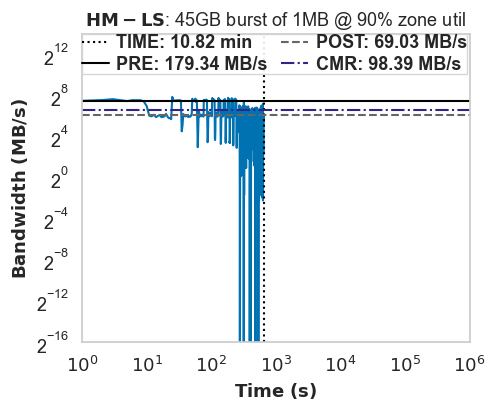

In [20]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped, color=series_colors['hmls'], linewidth=1.5)
plt.title(r"$\bf{HM-LS}$: 45GB burst of 1MB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=pre_bw, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE: ' + pre_bw_str)
plt.axhline(y=post_bw, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST: ' + post_bw_str)
plt.axhline(y=cmr_zipf_9010_1M_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_zipf_9010_1M_bw) + ' MB/s')
# plt.legend(loc='lower right', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
# plt.legend(
#     loc='lower right',
#     bbox_to_anchor=(1.0, 0.0),
#     prop={'size': 12.5, 'weight': 'semibold'},
#     borderaxespad=0.0,              # no padding between axes and legend box
#     borderpad=0.2,                  # minimal padding inside legend frame
#     frameon=False,
#     fancybox=False,
#     shadow=False,
#     framealpha=0.9,
#     edgecolor='lightgray',
#     fontsize=12.5,
#     markerscale=0.7,        # scales down marker size
#     handlelength=1,         # length of line in legend
#     handletextpad=0.5       # spacing between line and text
# )
plt.legend(
    loc='upper left',
    ncols=2,
    prop={'size':13, 'weight':'semibold'},  # Reduce font size
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=13,  # Reduce legend font size
    borderaxespad=0.0,   # Reduce padding between legend and axes
    borderpad=0.0,       # Reduce padding inside the legend box
    handlelength=1.5,       # Shorten legend handles
    handletextpad=0.4,
    labelspacing=0.2,     # Reduce vertical space between labels
    columnspacing=0.75     # Reduce horizontal space between columns
)
plt.savefig('fig/fast2026/1M_90Util_HM-LS_BW_newCalc.pdf', bbox_inches='tight',dpi=500)
plt.show()

### HM-LS 90% Util, 1MB Uniform Random Writes

In [21]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/lsdm/90Util/1MB/8TB/uniform/45GB/round2/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576 #1MB
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())

/var/folders/2k/prv9ywh52sn57l626bl42pz40000gp/T/ipykernel_9694/1770814560.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538929
 12850.80538929 12850.80538929 12850.80538929 12850.80538

46079
             index  data_written_bytes  cumulative_gb
count  3470.000000         3470.000000    3470.000000
mean   1734.500000           13.279539      35.975505
std    1001.847044           36.603070       8.318411
min       0.000000            0.000000       0.151609
25%     867.250000            1.119774      34.191052
50%    1734.500000            1.413499      37.686997
75%    2601.750000            2.976776      41.418080
max    3469.000000          245.464523      45.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3470 entries, 0 to 3469
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               3470 non-null   int64  
 1   data_written_bytes  3470 non-null   float64
 2   cumulative_gb       3470 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 81.5 KB
None


In [22]:
##############################################
# HM-LS Pre and Post bandwidth drop
##############################################
print(df_grouped[:20])
pre_bw, post_bw, pre_bw_str, post_bw_str = compute_avg_bandwidth_drop(df_grouped)
print("Pre Drop Avg BW (MB/s):", pre_bw)
print("Post Drop Avg BW (MB/s):", post_bw)


    index  data_written_bytes  cumulative_gb
0       0          155.247676       0.151609
1       1          180.534093       0.327912
2       2          190.503838       0.513951
3       3          191.494048       0.700957
4       4          189.386290       0.885904
5       5          182.242128       1.063875
6       6          187.846481       1.247319
7       7          188.191945       1.431100
8       8          189.904132       1.616553
9       9          163.098757       1.775829
10     10           55.121034       1.829659
11     11           35.221025       1.864054
12     12           47.799775       1.910734
13     13           48.404788       1.958004
14     14           47.906212       2.004787
15     15           44.788871       2.048526
16     16           42.090004       2.089630
17     17           43.948899       2.132549
18     18           42.398559       2.173954
19     19           44.073450       2.216994
Drop Index: 9
DataFrame before the drop:
   index  data

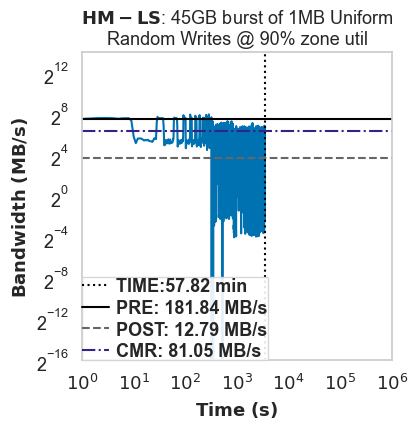

In [27]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(4, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped, color=series_colors['hmls'], linewidth=1.5)
plt.title(r"$\bf{HM-LS}$: 45GB burst of 1MB Uniform" "\n" "Random Writes @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME:' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=pre_bw, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE: ' + pre_bw_str)
plt.axhline(y=post_bw, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST: ' + post_bw_str)
plt.axhline(y=cmr_uniform_1M_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_uniform_1M_bw) + ' MB/s')
# plt.legend(loc='lower left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False,
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
# plt.legend(
#     loc='lower left',
#     bbox_to_anchor=(0.0, 0.01),
#     prop={'size': 12.5, 'weight': 'semibold'},
#     borderaxespad=0.2,              # no padding between axes and legend box
#     borderpad=0.2,                  # minimal padding inside legend frame
#     frameon=True,
#     fancybox=False,
#     shadow=False,
#     framealpha=0.5,
#     edgecolor='lightgray',
#     fontsize=12.5,
#     markerscale=0.7,        # scales down marker size
#     handlelength=1,         # length of line in legend
#     handletextpad=0.5       # spacing between line and text
# )
plt.legend(
    loc='lower left',
    ncols=1,
    prop={'size':13, 'weight':'semibold'},  # Reduce font size
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=13,  # Reduce legend font size
    borderaxespad=0.0,   # Reduce padding between legend and axes
    borderpad=0.0,       # Reduce padding inside the legend box
    handlelength=1.5,       # Shorten legend handles
    handletextpad=0.4,
    labelspacing=0.2,     # Reduce vertical space between labels
    columnspacing=0.75     # Reduce horizontal space between columns
)
plt.savefig('fig/fast2026/1M_90Util_Uniform_HM-LS_BW_newCalc.pdf', bbox_inches='tight',dpi=500)
plt.show()

### HM-LS 90% Util, 4KB 90-10 LBA Random Writes

In [29]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/lsdm/4K/90-10-LBA/90Util/run2/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 4096  # 4KB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################

# data_array_vec = df_grouped_vec['data_written_bytes'].values.reshape(-1, 1)
# kmeans = KMeans(n_clusters=2)
# kmeans.fit(data_array_vec)
# # Get the cluster centers
# cluster_centers_vec = kmeans.cluster_centers_.flatten()
# # Sort cluster centers to get the lowest and highest modes
# cluster_centers_vec.sort()
# # Calculate the average of each mode
# average_mode1_vec = cluster_centers_vec[0]
# average_mode2_vec = cluster_centers_vec[1]
# print("Average1: " + str(round(average_mode1_vec, )))
# print("Average2: " + str(round(average_mode2_vec, )))
# avg_bw_str1 = str(round(average_mode1_vec, 2)) + ' MB/s'
# avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'
##############################################
# HM-LS Pre and Post bandwidth drop
##############################################
print(df_grouped_vec[:20])
pre_bw, post_bw, pre_bw_str, post_bw_str = compute_avg_bandwidth_drop(df_grouped_vec)
print("Pre Drop Avg BW (MB/s):", pre_bw)
print("Post Drop Avg BW (MB/s):", post_bw)


             index  data_written_bytes  cumulative_gb
count  1857.000000         1857.000000    1857.000000
mean    928.000000            2.757135       2.778088
std     536.214043           13.814532       1.333407
min       0.000000            0.000000       0.040176
25%     464.000000            0.046855       1.506765
50%     928.000000            0.047665       2.841485
75%    1392.000000            0.048279       3.845278
max    1856.000000          177.698510       5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               1857 non-null   int64  
 1   data_written_bytes  1857 non-null   float64
 2   cumulative_gb       1857 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 43.7 KB
None
    index  data_written_bytes  cumulative_gb
0       0           41.140625       0.040176
1       1        

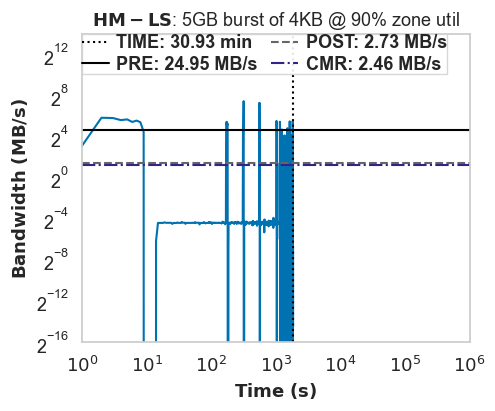

In [32]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color=series_colors['hmls'], linewidth=1.5)
plt.title(r"$\bf{HM-LS}$: 5GB burst of 4KB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=pre_bw, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE: ' + pre_bw_str)
plt.axhline(y=post_bw, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST: ' + post_bw_str)
plt.axhline(y=cmr_zipf_9010_4K_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_zipf_9010_4K_bw) + ' MB/s')
# plt.legend(loc='lower right', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
# plt.legend(
#     loc='lower right',
#     bbox_to_anchor=(1.0, 0.01),
#     prop={'size': 12, 'weight': 'semibold'},
#     borderaxespad=0.2,              # no padding between axes and legend box
#     borderpad=0.2,                  # minimal padding inside legend frame
#     frameon=True,
#     fancybox=False,
#     shadow=False,
#     framealpha=0.5,
#     edgecolor='lightgray',
#     fontsize=12,
#     markerscale=0.7,        # scales down marker size
#     handlelength=1,         # length of line in legend
#     handletextpad=0.5       # spacing between line and text
# )
plt.legend(
    loc='upper left',
    ncols=2,
    prop={'size':13, 'weight':'semibold'},  # Reduce font size
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=13,  # Reduce legend font size
    borderaxespad=0.0,   # Reduce padding between legend and axes
    borderpad=0.0,       # Reduce padding inside the legend box
    handlelength=1.5,       # Shorten legend handles
    handletextpad=0.4,
    labelspacing=0.2,     # Reduce vertical space between labels
    columnspacing=0.75     # Reduce horizontal space between columns
)
plt.savefig('fig/fast2026/4KB_90Util_90-10_LBA_HM-LS_BW_newCalc.pdf', bbox_inches='tight',dpi=500)
plt.show()

### HM-LS 90% Util, 4KB Uniform Random Writes

```python

In [52]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/lsdm/lsdm-util/90Util/4KB/8TB/uniform-random/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 4096  # 4KB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################
# HM-LS Pre and Post bandwidth drop
##############################################
print(df_grouped_vec[:20])
pre_bw, post_bw, pre_bw_str, post_bw_str = compute_avg_bandwidth_drop(df_grouped_vec)
print("Pre Drop Avg BW (MB/s):", pre_bw)
print("Post Drop Avg BW (MB/s):", post_bw)

             index  data_written_bytes  cumulative_gb
count  5476.000000         5476.000000    5476.000000
mean   2737.500000            0.934989       2.728459
std    1580.929368           11.476394       1.318113
min       0.000000            0.000000       0.029500
25%    1368.750000            0.046720       2.150071
50%    2737.500000            0.047179       2.211944
75%    4106.250000            0.047663       4.012100
max    5475.000000          194.000010       5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5476 entries, 0 to 5475
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               5476 non-null   int64  
 1   data_written_bytes  5476 non-null   float64
 2   cumulative_gb       5476 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 128.5 KB
None
    index  data_written_bytes  cumulative_gb
0       0           30.208088       0.029500
1       1       

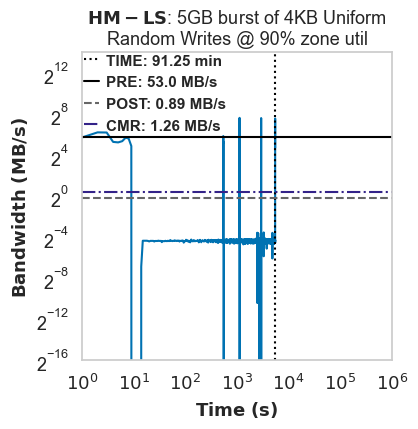

In [59]:
# pre_bw_str = str(round(pre_bw, 2)) + '\nMB/s'
# post_bw_str = str(round(post_bw, 2)) + '\n         MB/s'

#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(4, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color=series_colors['hmls'], linewidth=1.5)
plt.title(r"$\bf{HM-LS}$: 5GB burst of 4KB Uniform" "\n" "Random Writes @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=pre_bw, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE: ' + pre_bw_str)
plt.axhline(y=post_bw, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST: ' + post_bw_str)
plt.axhline(y=cmr_uniform_4K_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_uniform_4K_bw) + ' MB/s')
# plt.legend(loc='lower right', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, 1),
    prop={'size': 11, 'weight': 'semibold'},
    borderaxespad=0.0,              # no padding between axes and legend box
    borderpad=0.1,                  # minimal padding inside legend frame
    frameon=False,
    fancybox=False,
    shadow=False,
    framealpha=0.5,
    edgecolor='lightgray',
    fontsize=11,
    markerscale=0.7,        # scales down marker size
    handlelength=1,         # length of line in legend
    handletextpad=0.5       # spacing between line and text
)
# plt.legend(
#     loc='upper left',
#     ncols=2,
#     prop={'size':13, 'weight':'semibold'},  # Reduce font size
#     frameon=False,
#     fancybox=False,
#     shadow=False,
#     framealpha=0.9,
#     edgecolor='lightgray',
#     fontsize=13,  # Reduce legend font size
#     borderaxespad=0.0,   # Reduce padding between legend and axes
#     borderpad=0.0,       # Reduce padding inside the legend box
#     handlelength=1.25,       # Shorten legend handles
#     handletextpad=0.4,
#     labelspacing=0.2,     # Reduce vertical space between labels
#     columnspacing=0.75     # Reduce horizontal space between columns
# )
plt.savefig('fig/fast2026/4KB_90Util_Uniform_HM-LS_BW_newCalc.pdf', bbox_inches='tight',dpi=500)
plt.show()

## HM-LS 90% Util, 4KB Uniform Random Writes 90% Util - New Calculation

In [63]:
# # Define a custom grouping function
  
# names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
# columns = ['submission_time', 'duration', 'write_size']

# # Step 1: Read the CSV file into a Pandas DataFrame
# df = pd.read_csv(f'fast2026/Sep6-2025/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

# df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
# df['duration'] = df['duration']/1e6 #convert ns to ms
# df['completion_time'] = df['submission_time'] + df['duration']

# # Step 3: Determine time range
# start_time = df['submission_time'].min()
# end_time = math.ceil(df['completion_time'].max())

# # Pre-compute all values vectorized
# df_vec = df.copy()
# df_vec['duration'] = df_vec['duration'].astype(float)
# df_vec['start'] = df_vec['submission_time'].astype(int)
# df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

# payload = 4096  # 4KB
# df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
# df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
# df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# # Create result array (much faster than DataFrame for this operation)
# time_range = end_time - start_time + 1
# data_written_array = np.zeros(time_range)

# # Vectorized assignment using advanced indexing
# for _, row in df_vec.iterrows():
#     start_idx = int(row['start'] - start_time)
#     end_idx = int(row['end'] - start_time)
    
#     if end_idx > start_idx:
#         data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
#     if end_idx < len(data_written_array):
#         data_written_array[end_idx] += row['residue']

# # Convert back to DataFrame only at the end
# data_written_ms_vec = pd.DataFrame({
#     'data_written_bytes': data_written_array
# }, index=range(start_time, end_time + 1))

# # Find last non-zero more efficiently
# non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
# if non_zero_mask.any():
#     last_non_zero_index = non_zero_mask[::-1].idxmax()
#     data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

# data_written_ms_vec.reset_index(drop=True, inplace=True)

# ##################################

# chunk_size = 10000
# results = []
# for i in range(0, len(data_written_ms_vec), chunk_size):
#     chunk = data_written_ms_vec.iloc[i:i+chunk_size]
#     result = chunk.groupby(custom_grouping).sum()
#     results.append(result)

# df_grouped_vec = pd.concat(results)

# # Reset the index to make it a regular column
# df_grouped_vec.reset_index(inplace=True)
# df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
# df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
# #
# #data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
# print(df_grouped_vec.describe())
# print(df_grouped_vec.info())

# ####################

# # HM-LS Pre and Post bandwidth drop
# ##############################################
# print(df_grouped_vec[:20])
# pre_bw, post_bw, pre_bw_str, post_bw_str = compute_avg_bandwidth_drop(df_grouped_vec)
# print("Pre Drop Avg BW (MB/s):", pre_bw)
# print("Post Drop Avg BW (MB/s):", post_bw)


In [64]:
# #now plot the data with seaborn
# #remove the grid and use white background
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(4, 4))
# plt.grid(False)
# ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color=series_colors['hmls'], linewidth=1.5)
# plt.title(r"$\bf{HM-LS}$: 5GB burst of 4KB Uniform" "\n" "Random Writes @ 90% zone util", fontsize=13)

# common_yticks = [2**i for i in range(-16, 14, 2)]
# plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# # Custom formatter to display ticks as powers of 2
# def log2_format(y, pos):
#     return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# lowest_power_of_2 = 2 ** -16
# ax.set_ylim(lowest_power_of_2 , 2**14)
# ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
# #set x-axis to log scale
# ax.set_xscale('log', base=10)
# #set y-axis to log base 2 scale
# ax.set_yscale('log', base=2)
# plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# # Custom formatter to display ticks as powers of 10
# def log10_format(y, pos):
#     return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

# common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
# ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
# ax.set_xlim(10**0, 10**5)
# plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
# xmax = df_grouped_vec.index.max()
# # Add a vertical line at the end of the experiment
# xmin = round(int(xmax)/60, 2)
# ax.axvline(x=xmax, color='black', linestyle=':', label='TIME:' + str(xmin) + ' min')
# plt.xticks(fontsize=13)
# plt.yticks(fontsize=13)
# plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

# plt.axhline(y=pre_bw, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE:' + pre_bw_str)
# plt.axhline(y=post_bw, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST:' + post_bw_str)
# plt.axhline(y=cmr_uniform_4K_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_uniform_4K_bw) + ' MB/s')
# # plt.legend(loc='lower right', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
# #            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13, markerscale=0.1)
# plt.legend(
#     loc='upper left',
#     bbox_to_anchor=(0, 1),
#     prop={'size': 12, 'weight': 'semibold'},
#     borderaxespad=0.1,              # no padding between axes and legend box
#     borderpad=0.1,                  # minimal padding inside legend frame
#     frameon=True,
#     fancybox=False,
#     shadow=False,
#     framealpha=0.5,
#     edgecolor='lightgray',
#     fontsize=12,
#     markerscale=0.7,        # scales down marker size
#     handlelength=2,         # length of line in legend
#     handletextpad=0.5       # spacing between line and text
# )
# plt.savefig('fig/fast2026/4KB_90Util_Uniform_HM-LS_BW_newCalc.pdf', bbox_inches='tight',dpi=500)
# plt.show()